In [7]:
import sys
import pandas as pd

# 1. CARGAR LOS DATOS 
df = pd.read_csv('../data/raw/NHANES.csv')

# 2. DEFINIR EL DICCIONARIO
nombres_claros = {
    'SEQN': 'id_secuencia',
    'age_group': 'grupo_edad',
    'RIDAGEYR': 'edad',
    'RIAGENDR': 'genero',
    'PAQ605': 'actividad_fisica',
    'BMXBMI': 'imc',
    'LBXGLU': 'glucosa_ayunas',
    'DIQ010': 'es_diabetico',
    'LBXGLT': 'test_glucosa_oral',
    'LBXIN': 'insulina'
}

# 3. RENOMBRAR (Ahora sí, 'df' ya existe POR ESE PUTO PROBLEMA QUE ME TENÍA PODRIDO)
df = df.rename(columns=nombres_claros)

# 4. VERIFICAR
print("--- Columnas actualizadas con éxito ---")
print(df.columns)
df.head() 

--- Columnas actualizadas con éxito ---
Index(['id_secuencia', 'grupo_edad', 'edad', 'genero', 'actividad_fisica',
       'imc', 'glucosa_ayunas', 'es_diabetico', 'test_glucosa_oral',
       'insulina'],
      dtype='object')


,id_secuencia,grupo_edad,edad,genero,actividad_fisica,imc,glucosa_ayunas,es_diabetico,test_glucosa_oral,insulina
0,73564.0,Adult,61.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91
1,73568.0,Adult,26.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85
2,73576.0,Adult,16.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14
3,73577.0,Adult,32.0,1.0,2.0,28.9,104.0,2.0,84.0,16.15
4,73580.0,Adult,38.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92


In [8]:
# 1. vamos a actualizar las listas con los nuevos nombres
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# 2. todo debe funcionar, calculamos mean (media), median (mediana) std (desviación estandar) min y max
print("--- ESTADÍSTICAS NUMÉRICAS ---")
desc_num = df[numeric_cols].describe().T
desc_num['median'] = df[numeric_cols].median()
print(desc_num[['mean', 'median', 'std', 'min', 'max']])

# 3. Frecuencia de categóricas
print("\n--- FRECUENCIA DE CATEGÓRICAS ---")
for col in categorical_cols:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())

--- ESTADÍSTICAS NUMÉRICAS ---
                           mean    median          std       min       max
id_secuencia       78691.853819  78749.00  2921.365151  73564.00  83727.00
edad                  41.795874     41.00    20.156111     12.00     80.00
genero                 1.511414      2.00     0.499979      1.00      2.00
actividad_fisica       1.822651      2.00     0.398918      1.00      7.00
imc                   27.955180     26.80     7.248962     14.50     70.10
glucosa_ayunas        99.553117     97.00    17.889834     63.00    405.00
es_diabetico           2.016242      2.00     0.185556      1.00      3.00
test_glucosa_oral    114.978929    105.00    47.061239     40.00    604.00
insulina              11.834794      9.04     9.718812      0.14    102.29

--- FRECUENCIA DE CATEGÓRICAS ---

Columna: grupo_edad
grupo_edad
Adult     1914
Senior     364
Name: count, dtype: int64


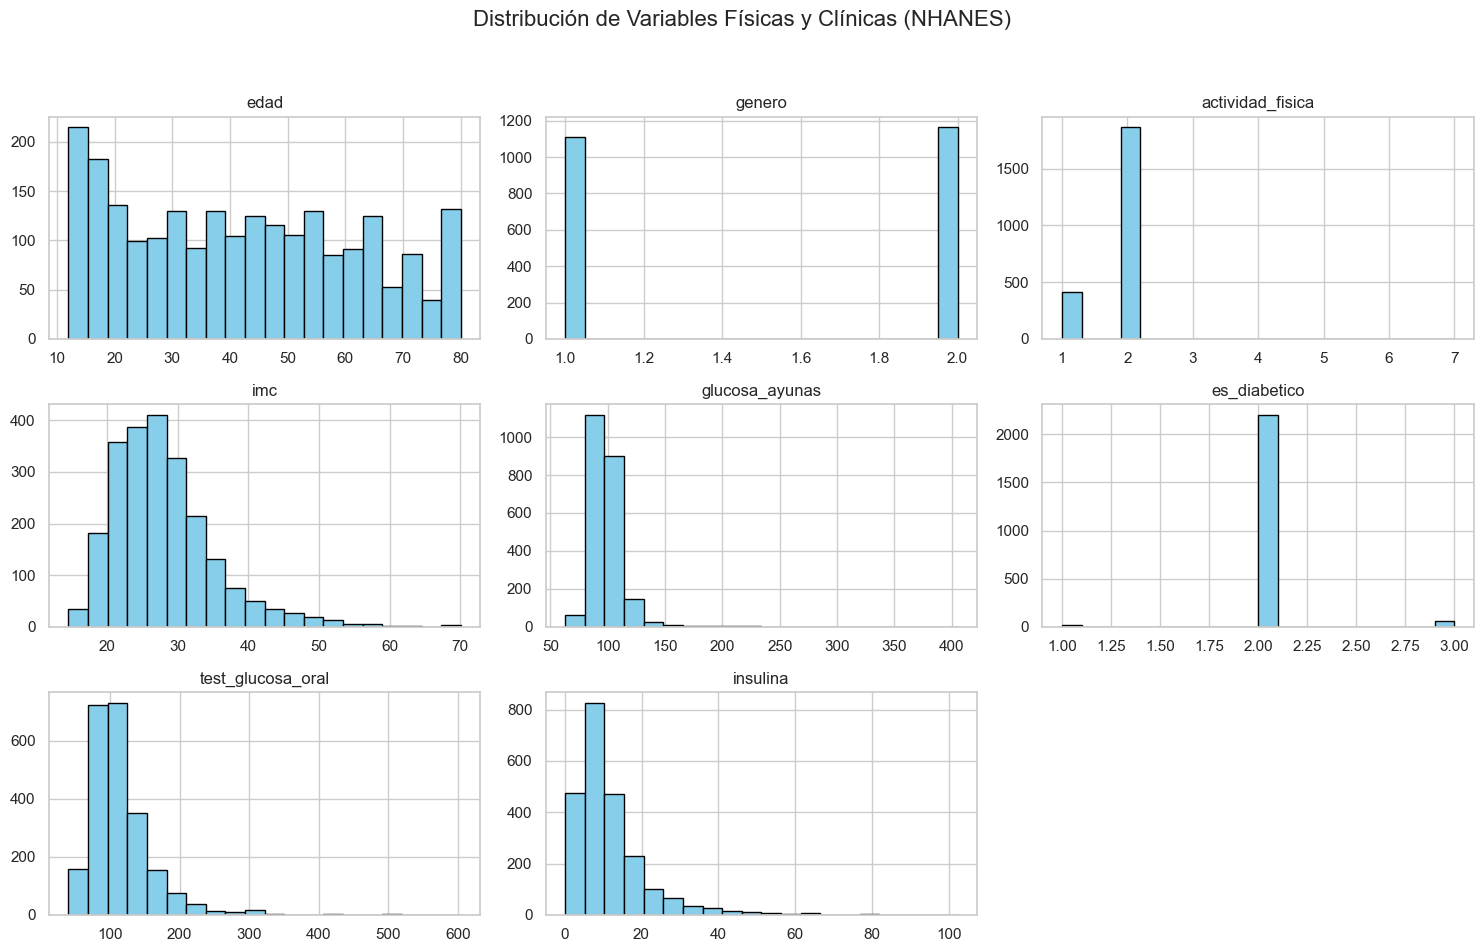

In [9]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
# Filtramos la lista de columnas numéricas para ignorar el ID
cols_analisis = [c for c in numeric_cols if c != 'id_secuencia']

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Creamos histogramas solo para las variables reales
df[cols_analisis].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Físicas y Clínicas (NHANES)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que el título no tape las gráficas
plt.show()

In [10]:
# 1. Crear diccionarios de mapeo 
mapeo_genero = {1: 'Masculino', 2: 'Femenino'}
mapeo_actividad = {1: 'Activo', 2: 'Inactivo', 7: 'No sabe/Refuso'}
mapeo_diabetes = {1: 'Si', 2: 'No', 3: 'Fronterizo'}

# 2. Aplicar el cambio a las columnas
df['genero'] = df['genero'].map(mapeo_genero)
df['actividad_fisica'] = df['actividad_fisica'].map(mapeo_actividad)
df['es_diabetico'] = df['es_diabetico'].map(mapeo_diabetes)

# 3. Limpieza: id_secuencia NO es una variable para promediar, es un ID.
# La quitamos de la lista de numéricas para que no ensucie el análisis.
if 'id_secuencia' in numeric_cols:
    numeric_cols.remove('id_secuencia')

# 4. RE-IDENTIFICAR las columnas (esto moverá genero y actividad a categorical_cols)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Variables ahora en Categorical:", categorical_cols)

Variables ahora en Categorical: ['grupo_edad', 'genero', 'actividad_fisica', 'es_diabetico']


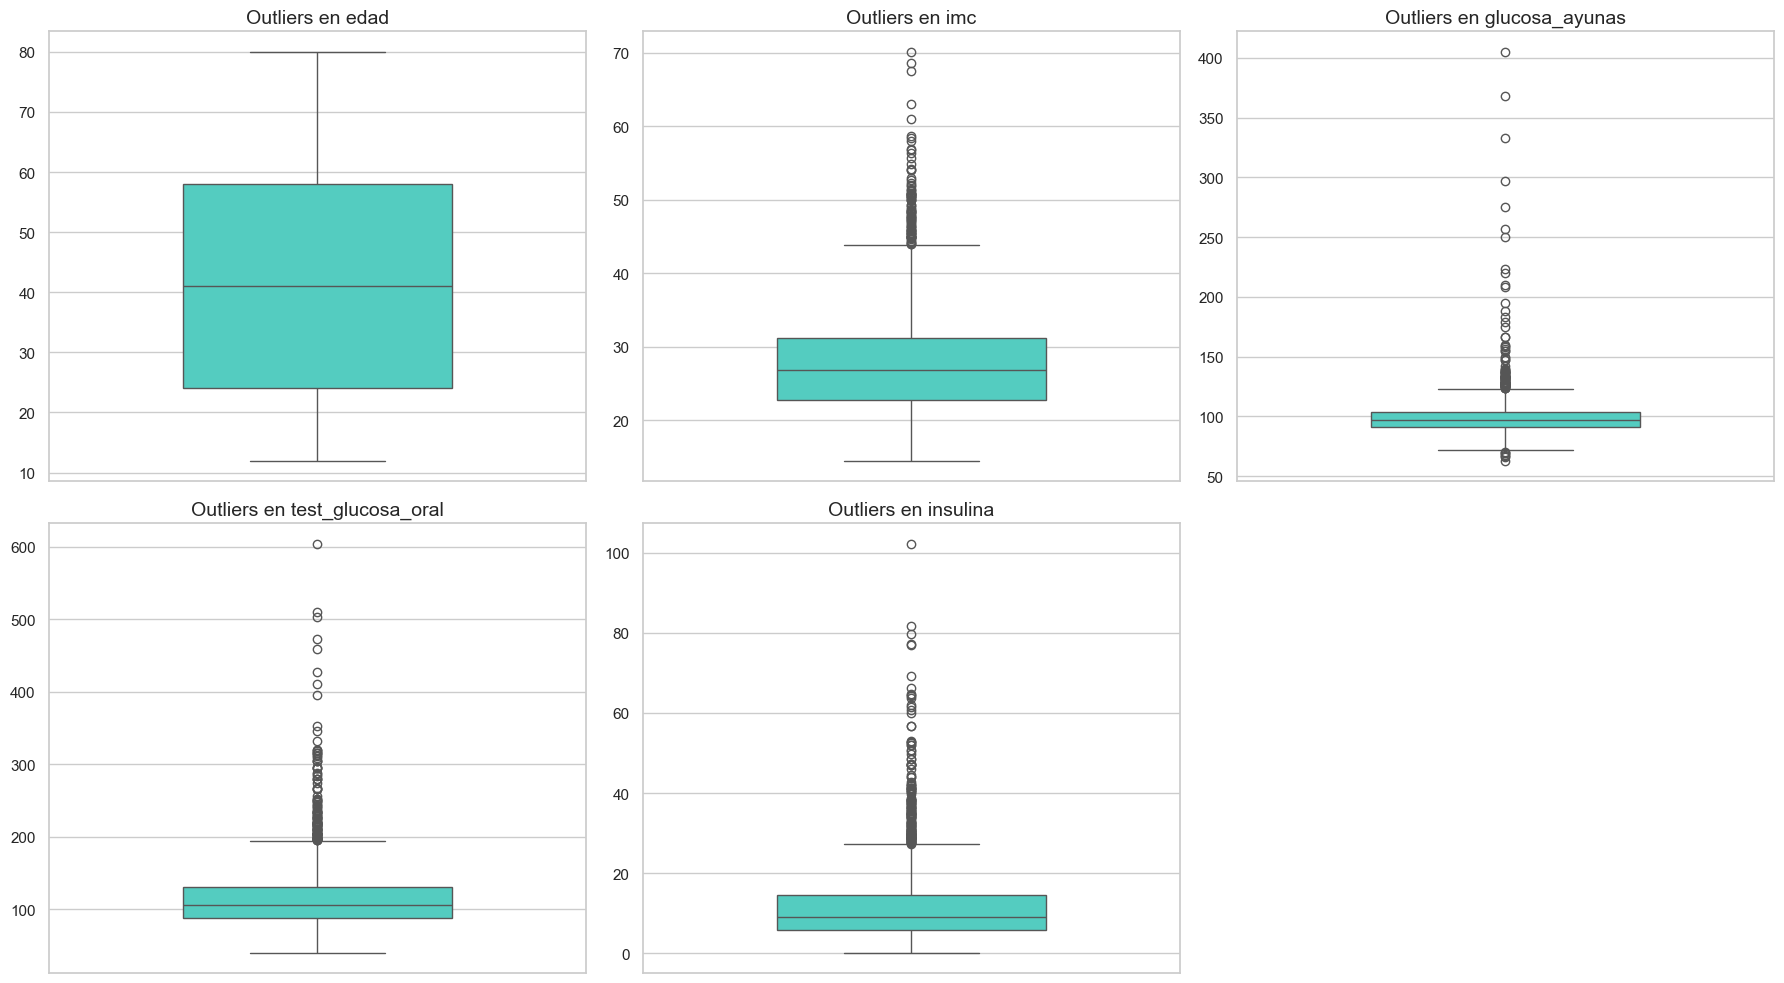

In [11]:
# 1. Lista de análisis (sin el ID)
cols_analisis = [c for c in numeric_cols if c != 'id_secuencia']

# 2. Configurar el lienzo (2 filas, 3 columnas = 6 espacios)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

# 3. Dibujar un boxplot por cada variable real
for i, col in enumerate(cols_analisis):
    sns.boxplot(y=df[col], ax=axes[i], color='turquoise', width=0.5)
    axes[i].set_title(f"Outliers en {col}", fontsize=14)
    axes[i].set_ylabel("")

# 4. OCULTAR el sexto cuadro (el que sobra)
if len(cols_analisis) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

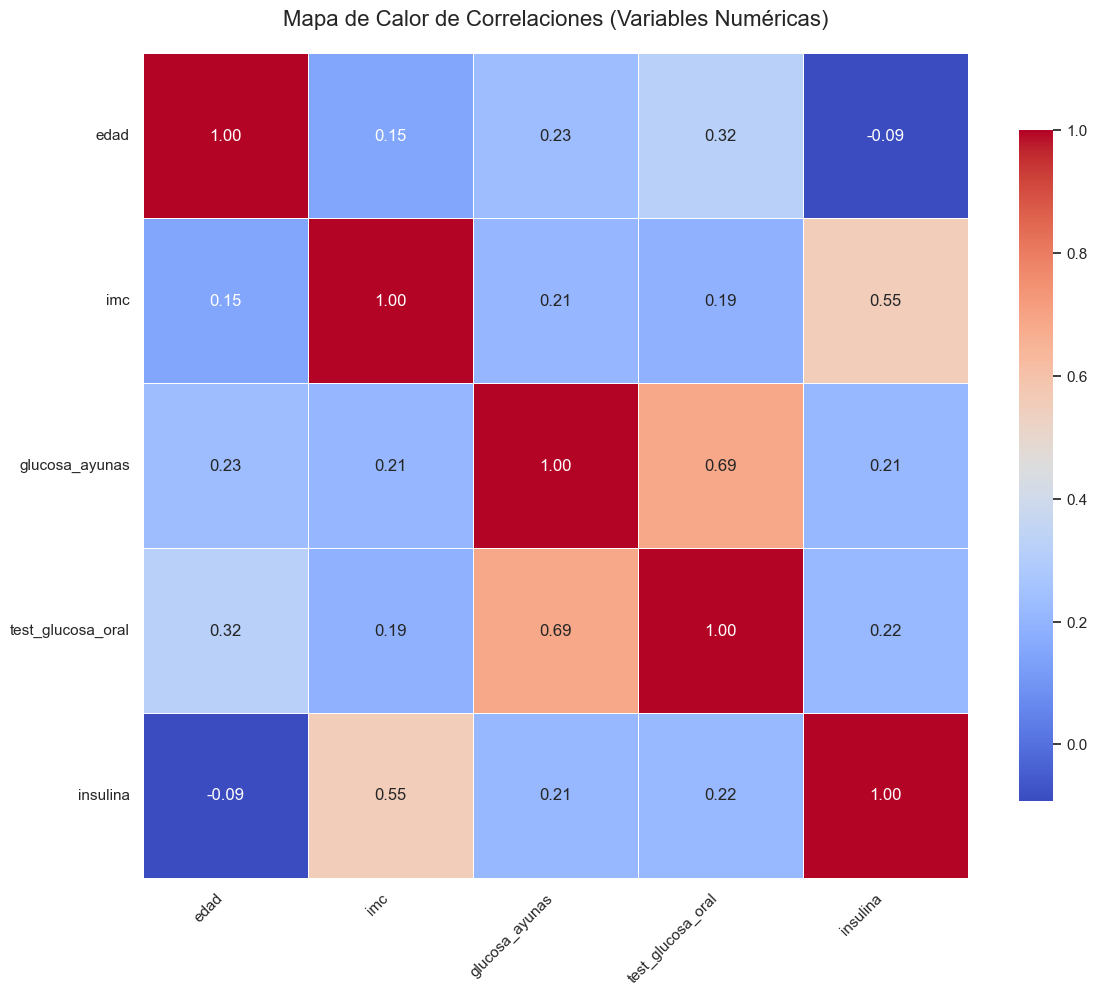

In [12]:
# 4. Matriz de correlación - Versión Mejorada
plt.figure(figsize=(12, 10)) # Aumentamos un poco el tamaño

# Calculamos la correlación
corr_matrix = df[cols_analisis].corr()

# Dibujamos el mapa
# 'annot' pone los números, 'fmt' los decimales
# 'cbar_kws' permite ajustar la barra de color si fuera necesario
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})

# AJUSTE DE ETIQUETAS:
# Rotamos las de abajo 45 grados y las alineamos a la derecha
plt.xticks(rotation=45, ha='right')
# Las del eje Y las dejamos horizontales pero nos aseguramos de que tengan espacio
plt.yticks(rotation=0)

plt.title("Mapa de Calor de Correlaciones (Variables Numéricas)", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

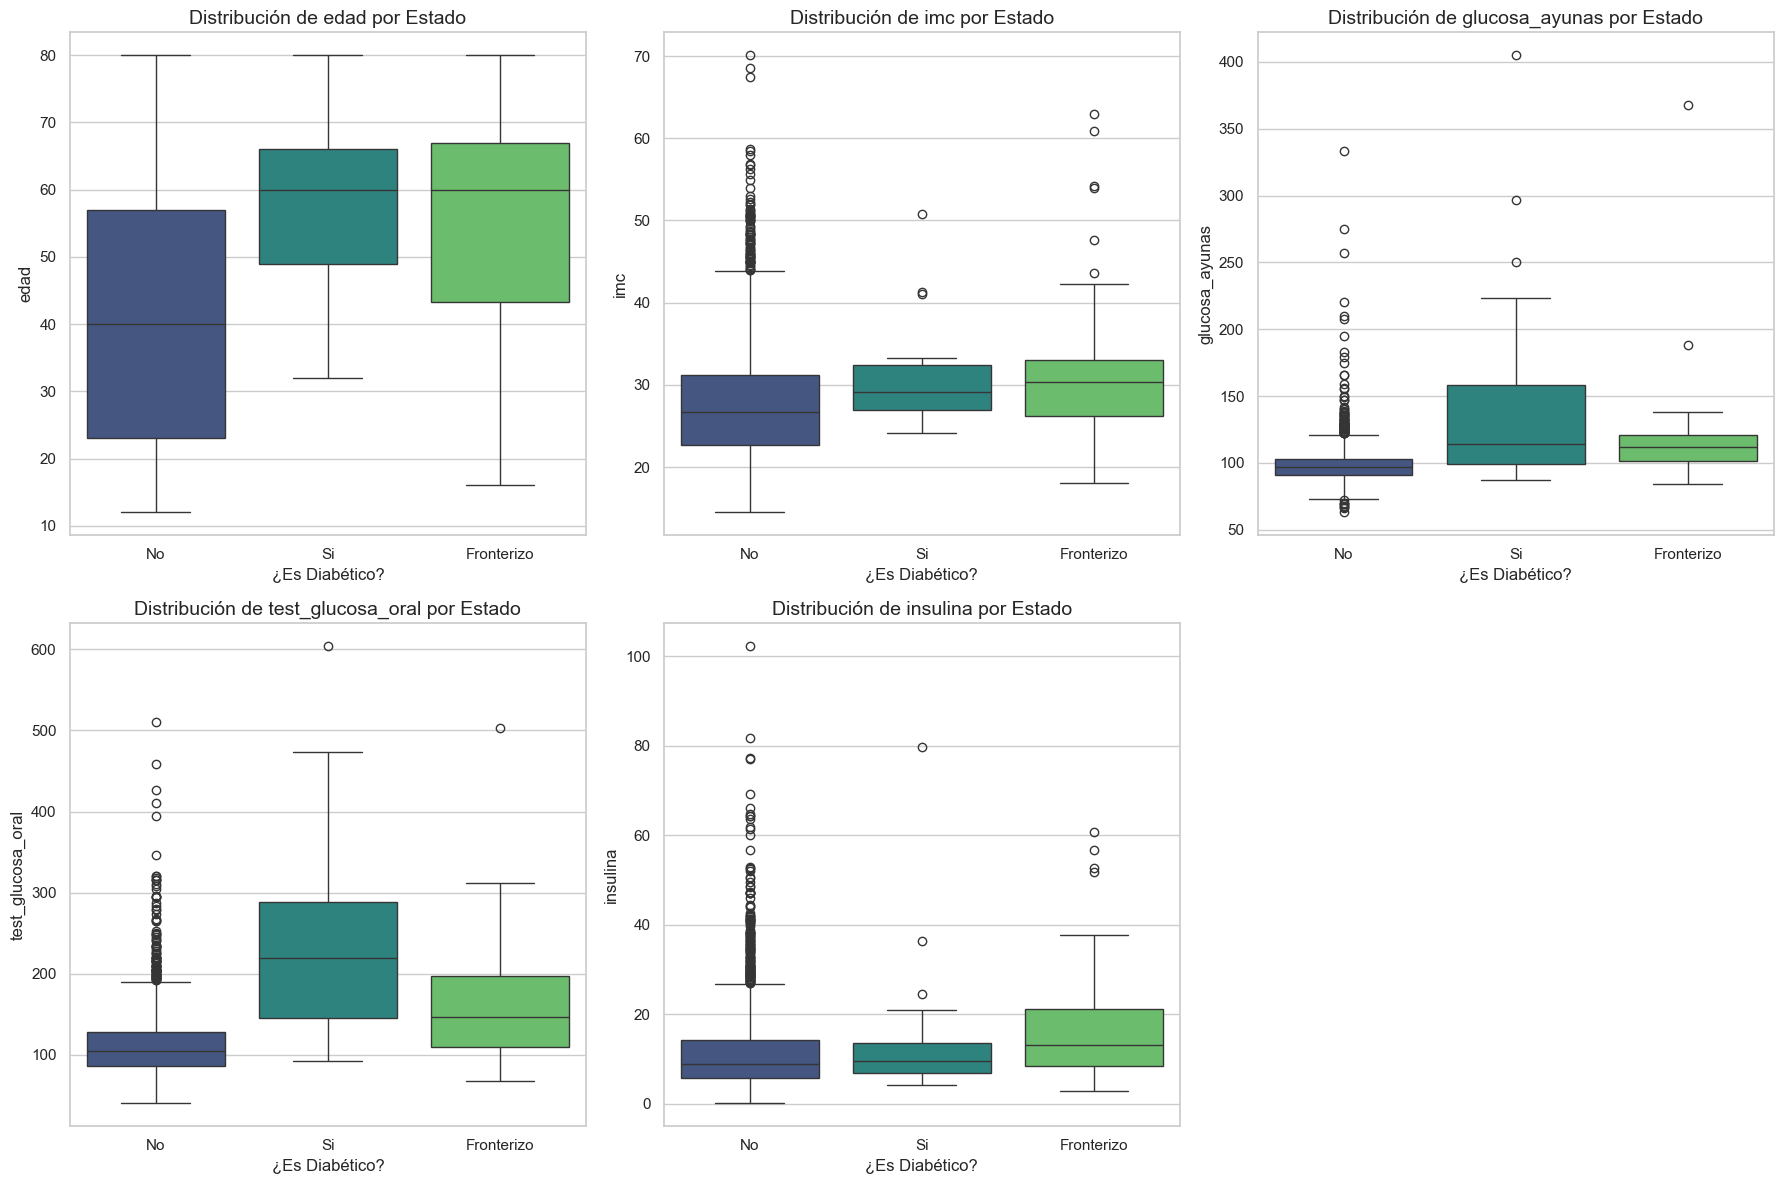

In [13]:
# 5. Boxplots comparativos
col_target = 'es_diabetico'

# CONFIGURACIÓN DE COLORES: 
# podré usar: "viridis", "magma", "rocket", "crest", "flare" o "pastel", voy explorando a ver cual me parece linda
mi_paleta = "viridis" 

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_analisis):
    # Añadimos hue=col_target y legend=False para quitar el aviso
    sns.boxplot(x=col_target, y=col, data=df, ax=axes[i], 
                hue=col_target, palette=mi_paleta, legend=False)
    
    axes[i].set_title(f"Distribución de {col} por Estado", fontsize=14)
    axes[i].set_xlabel("¿Es Diabético?")

# Limpieza final
if len(cols_analisis) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import sqlite3
import os

# 1. Carga los datos desde tu base de datos SQLite
CARPETA_RAIZ = os.path.abspath(os.path.join(os.path.dirname('__file__'), ".."))
ruta_db = os.path.join(CARPETA_RAIZ, "database", "proyecto_analitica.db")
conexion = sqlite3.connect(ruta_db)

# Cargamos la tabla de clasificación
df_nhanes = pd.read_sql_query("SELECT * FROM clasificacion_nhanes", conexion)
conexion.close()

# 2. Reporte de nulos
print("📊 REPORTE DE VALORES FALTANTES - NHANES")
print("-" * 40)
nulos_totales = df_nhanes.isnull().sum()
nulos_porcentaje = (nulos_totales / len(df_nhanes)) * 100

reporte_nulos = pd.concat([nulos_totales, nulos_porcentaje], axis=1, keys=['Total Nulos', '%'])
display(reporte_nulos[reporte_nulos['Total Nulos'] >= 0]) # Mostramos todo para evidencia

📊 REPORTE DE VALORES FALTANTES - NHANES
----------------------------------------


,Total Nulos,%
SEQN,0,0.0
age_group,0,0.0
RIDAGEYR,0,0.0
RIAGENDR,0,0.0
PAQ605,0,0.0
BMXBMI,0,0.0
LBXGLU,0,0.0
DIQ010,0,0.0
LBXGLT,0,0.0
LBXIN,0,0.0


In [13]:
import os

# 1. Crear la carpeta 'processed' si no existe
ruta_processed = '../data/processed/'
os.makedirs(ruta_processed, exist_ok=True)

# 2. Guardar el dataset de NHANES verificado
# Aquí usamos 'df' porque es el que ya tiene los nombres en español
df.to_csv(os.path.join(ruta_processed, 'nhanes_limpio.csv'), index=False)

print(f"✅ Archivo guardado en: {os.path.join(ruta_processed, 'nhanes_limpio.csv')}")

✅ Archivo guardado en: ../data/processed/nhanes_limpio.csv


In [17]:
from scipy.stats import chi2_contingency

def prueba_chi2(df, var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"Test Chi2 entre {var1} y {var2}:")
    print(f"p-value: {p:.6f}")
    print("✅ Hay dependencia significativa" if p < 0.05 else "❌ Son independientes")

prueba_chi2(df, 'genero', 'es_diabetico')
prueba_chi2(df, 'actividad_fisica', 'es_diabetico')


Test Chi2 entre genero y es_diabetico:
p-value: 0.288829
❌ Son independientes
Test Chi2 entre actividad_fisica y es_diabetico:
p-value: 0.645996
❌ Son independientes


In [18]:
from scipy import stats

# 1. Definimos la función de tu guía (Pág 26)
def analisis_dependencia_num(data, x, y, alpha=0.05):
    # x: categórica (Target), y: numérica (Feature)
    df_temp = data[[x, y]].dropna()
    grupos = [df_temp[df_temp[x] == cat][y] for cat in df_temp[x].unique()]
    
    # Prueba de Kruskal-Wallis (No paramétrica, ideal para salud)
    H, p_kruskal = stats.kruskal(*grupos)
    
    print(f"🧪 ANALIZANDO: {y} según {x}")
    print(f"p-value (Kruskal): {p_kruskal:.10f}")
    
    if p_kruskal < alpha:
        print("✅ CONCLUSIÓN: Hay una dependencia fuerte. Los valores cambian según el grupo.")
    else:
        print("❌ CONCLUSIÓN: Los valores son similares. No hay dependencia clara.")
    print("-" * 50)

# 2. Ejecutamos para tus variables numéricas de salud
# Aquí comparamos la Glucosa y el IMC contra el estado de Diabetes
analisis_dependencia_num(df, 'es_diabetico', 'glucosa_ayunas')
analisis_dependencia_num(df, 'es_diabetico', 'imc')

🧪 ANALIZANDO: glucosa_ayunas según es_diabetico
p-value (Kruskal): 0.0000000000
✅ CONCLUSIÓN: Hay una dependencia fuerte. Los valores cambian según el grupo.
--------------------------------------------------
🧪 ANALIZANDO: imc según es_diabetico
p-value (Kruskal): 0.0000763011
✅ CONCLUSIÓN: Hay una dependencia fuerte. Los valores cambian según el grupo.
--------------------------------------------------


<h3 align="center">Interpretación de Pruebas de Asociación y Dependencia (Clasificación)</h3>

<p>Después de ejecutar las pruebas de hipótesis, vamos a analizar los resultados para poder determinar qué variables aportan información relevante al estado diabético (es_diabetico):</p>

<table style="width:100%; border: none;">
<tr>
<th style="width: 50%; text-align: center; padding: 10px; font-size: 1.1em; border-bottom: 2px solid #4cc9f0;">A. Variables Categóricas (Prueba Chi-cuadrado)</th>
<th style="width: 50%; text-align: center; padding: 10px; font-size: 1.1em; border-bottom: 2px solid #4cc9f0;">B. Variables Mixtas (Prueba de Kruskal-Wallis)</th>
</tr>
<tr>
<td style="vertical-align: top; padding: 20px; border-right: 1px solid rgba(255,255,255,0.2);">
<h4 align="center">Género vs. Estado Diabético</h4>
<p>Se obtuvo un p-value = 0.2888.<br>Al ser mayor al nivel de significancia α = 0.05, no se rechaza la hipótesis nula (H_0).<br>Esto indica que en esta muestra, el género y la diabetes son independientes.</p>
<br>
<h4 align="center">Actividad Física vs. Estado Diabético</h4>
<p>El resultado arrojó un p-value = 0.6459.<br>Se concluye que no hay evidencia estadística suficiente para afirmar una relación; las variables son independientes y la actividad física no parece explicar por sí sola la presencia de la enfermedad en este conjunto de datos.</p>
</td>
<td style="vertical-align: top; padding: 20px;">
<h4 align="center">Glucosa en ayunas</h4>
<p>Se obtuvo un p-value ≈ 0. Al ser significativamente menor a 0.05, se rechaza H_0. Existe una dependencia muy fuerte; los niveles de glucosa varían drásticamente entre pacientes diabéticos y no diabéticos.</p>
<br>
<h4 align="center">IMC (Índice de Masa Corporal)</h4>
<p>Se obtuvo un p-value = 0.000076. Al ser menor a 0.05, se confirma que hay diferencias significativas entre las distribuciones. El peso corporal es un factor que presenta dependencia con el diagnóstico.</p>
</td>
</tr>
</table>